<a href="https://colab.research.google.com/github/Junaeid-Shoaib/Energy_Surplus_Forecasting-A_Time_Series_Odyssey/blob/main/brighton_forecast_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Setup, GPU check, seeds, plotting defaults

!pip install -q lightgbm > /dev/null 2>&1
!pip install tensorflow scikit-learn
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow: {tf.__version__}")
print(f"GPUs detected: {len(gpus)}")
if gpus:
    print(f"  -> {gpus[0].name}")
else:
    print("  WARNING: No GPU. Runtime -> Change runtime type -> T4 GPU")

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("Environment ready")

TensorFlow: 2.19.0
GPUs detected: 1
  -> /physical_device:GPU:0
Environment ready


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# Mount Drive, load all 128 CSVs
# Same approach as my MSc project, just pointed at Drive

import glob
import os

# Move into the data folder so glob('*.csv') works exactly like before
os.chdir('/content/drive/MyDrive/DataSscienceUpdated/Datasets')

def load_csv(filename):
    with open(filename, 'r') as file:
        first_line = file.readline()
        if first_line.replace(',', '').strip().isdigit():
            df = pd.read_csv(filename, skiprows=1)
        else:
            df = pd.read_csv(filename)
    return df

df = pd.concat(
    [load_csv(filename) for filename in glob.glob('*.csv')],
    ignore_index=True
)

print(f"Shape: {df.shape}")
df.head()

Shape: (122844, 16)


,datetime,temp,dew,humidity,precip,precipprob,preciptype,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex
0,2023-05-13T00:00:00,10.8,9.2,89.98,0.0,0.0,NaN,0.0,0.0,25.2,14.0,1024.2,100.0,0.0,0.0,0.0
1,2023-05-13T01:00:00,10.6,9.2,90.81,0.0,0.0,NaN,0.0,0.0,23.2,13.0,1024.1,100.0,0.0,0.0,0.0
2,2023-05-13T02:00:00,10.5,8.9,90.34,0.0,0.0,NaN,0.0,0.0,23.9,13.0,1023.8,100.0,0.0,0.0,0.0
3,2023-05-13T03:00:00,10.2,8.7,90.64,0.0,0.0,NaN,0.0,0.0,26.5,13.0,1023.7,100.0,0.0,0.0,0.0
4,2023-05-13T04:00:00,9.9,8.3,89.69,0.0,0.0,NaN,0.0,0.0,30.5,4.0,1023.9,100.0,0.0,0.0,0.0


In [22]:
# Make datetime the index, sort chronologically, handle duplicates

# Convert the datetime column from string to actual datetime objects
df['datetime'] = pd.to_datetime(df['datetime'])

# Set datetime as the index so we can use time-based operations
df = df.set_index('datetime')

# Sort by datetime (the 128 files might have loaded in odd order via glob)
df = df.sort_index()

# Check for duplicate timestamps
n_duplicates = df.index.duplicated().sum()
print(f"Duplicate timestamps: {n_duplicates}")

# Show the duplicates so we know what we are dealing with
if n_duplicates > 0:
    print("\nDuplicate rows (first few):")
    print(df[df.index.duplicated(keep=False)].head(6))

# Keep the last occurrence of each duplicate, drop the rest
df = df[~df.index.duplicated(keep='last')]

print(f"\nShape after dedup: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Duplicate timestamps: 14

Duplicate rows (first few):
                     temp   dew  humidity  precip  precipprob preciptype  \
datetime                                                                   
2010-10-31 01:00:00  12.4  10.6     88.49   0.000         0.0        NaN   
2010-10-31 01:00:00  12.4  10.3     87.33   0.000         0.0        NaN   
2011-10-30 01:00:00  14.4  12.5     88.08   0.000         0.0        NaN   
2011-10-30 01:00:00  14.2  12.3     88.87   0.000         0.0        NaN   
2012-10-28 01:00:00   2.6   0.9     88.68   0.112       100.0       rain   
2012-10-28 01:00:00   2.5   0.7     87.94   0.000         0.0        NaN   

                     snow  snowdepth  windspeed  winddir  sealevelpressure  \
datetime                                                                     
2010-10-31 01:00:00   0.0        0.0       15.0    145.0             996.2   
2010-10-31 01:00:00   0.0        0.0       17.9    142.0             996.0   
2011-10-30 01:00:00   0.0

In [23]:
# Reindex to a continuous hourly timeline so missing hours become visible

# Build the timeline we SHOULD have: every hour from start to end, no gaps
full_index = pd.date_range(start=df.index.min(),
                           end=df.index.max(),
                           freq='h')

print(f"Hours we have:     {len(df):,}")
print(f"Hours we expect:   {len(full_index):,}")
print(f"Missing hours:     {len(full_index) - len(df):,}")

# Reindex: any hour in full_index not present in df becomes a row of NaN
df = df.reindex(full_index)
df.index.name = 'datetime'

# Find which hours are entirely NaN (i.e. were missing, not just patchy)
all_nan_rows = df[df.isna().all(axis=1)]
print(f"\nFully-missing hours: {len(all_nan_rows)}")
print("\nAll missing timestamps:")
print(all_nan_rows.index.tolist())

Hours we have:     122,830
Hours we expect:   122,844
Missing hours:     14

Fully-missing hours: 14

All missing timestamps:
[Timestamp('2010-03-28 01:00:00'), Timestamp('2011-03-27 01:00:00'), Timestamp('2012-03-25 01:00:00'), Timestamp('2013-03-31 01:00:00'), Timestamp('2014-03-30 01:00:00'), Timestamp('2015-03-29 01:00:00'), Timestamp('2016-03-27 01:00:00'), Timestamp('2017-03-26 01:00:00'), Timestamp('2018-03-25 01:00:00'), Timestamp('2019-03-31 01:00:00'), Timestamp('2020-03-29 01:00:00'), Timestamp('2021-03-28 01:00:00'), Timestamp('2022-03-27 01:00:00'), Timestamp('2023-03-26 01:00:00')]


In [24]:
# Look at missing values, drop columns that are too sparse to use

# Count missing values per column
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

print("Missing values per column:")
print(pd.DataFrame({'count': missing, 'percent': missing_pct}))

Missing values per column:
                   count  percent
preciptype        111575    90.83
snowdepth          33575    27.33
snow               33044    26.90
sealevelpressure     539     0.44
solarenergy          378     0.31
uvindex              372     0.30
solarradiation       344     0.28
cloudcover           302     0.25
precipprob           300     0.24
precip               293     0.24
winddir              291     0.24
dew                  290     0.24
humidity             283     0.23
windspeed            275     0.22
temp                 268     0.22


In [25]:
# Drop columns we cannot use, fill remaining gaps with linear interpolation

# Drop the three columns where missingness is too high to recover
# - preciptype: 91% missing, and it is a category not a number anyway
# - snow, snowdepth: 27% missing, AND Brighton barely sees snow,
#   AND snow does not drive solar/wind output meaningfully here
df = df.drop(columns=['preciptype', 'snow', 'snowdepth'])

# Fill the remaining small gaps using linear interpolation along time
df = df.interpolate(method='time')

# Confirm everything is filled
print("Remaining missing values:")
print(df.isna().sum())
print(f"\nFinal shape: {df.shape}")

Remaining missing values:
temp                0
dew                 0
humidity            0
precip              0
precipprob          0
windspeed           0
winddir             0
sealevelpressure    0
cloudcover          0
solarradiation      0
solarenergy         0
uvindex             0
dtype: int64

Final shape: (122844, 12)


In [26]:
# Split data chronologically (NOT randomly) into train/val/test

# For time series, we MUST split by time, not randomly
# Train: 2010-01-01 to 2020-12-31 (11 years)
# Val:   2021-01-01 to 2021-12-31 (1 year, used to tune models)
# Test:  2022-01-01 to 2023-12-31 (2 years, FINAL evaluation only)

train = df.loc['2010-01-01':'2020-12-31'].copy()
val   = df.loc['2021-01-01':'2021-12-31'].copy()
test  = df.loc['2022-01-01':'2023-12-31'].copy()

print(f"Train: {train.index.min()} to {train.index.max()}  ({len(train):,} hours)")
print(f"Val:   {val.index.min()} to {val.index.max()}  ({len(val):,} hours)")
print(f"Test:  {test.index.min()} to {test.index.max()}  ({len(test):,} hours)")
print(f"\nTotal: {len(train) + len(val) + len(test):,} hours")
print(f"Original: {len(df):,} hours")

Train: 2010-01-01 00:00:00 to 2020-12-31 23:00:00  (96,432 hours)
Val:   2021-01-01 00:00:00 to 2021-12-31 23:00:00  (8,760 hours)
Test:  2022-01-01 00:00:00 to 2023-12-31 23:00:00  (17,520 hours)

Total: 122,712 hours
Original: 122,844 hours


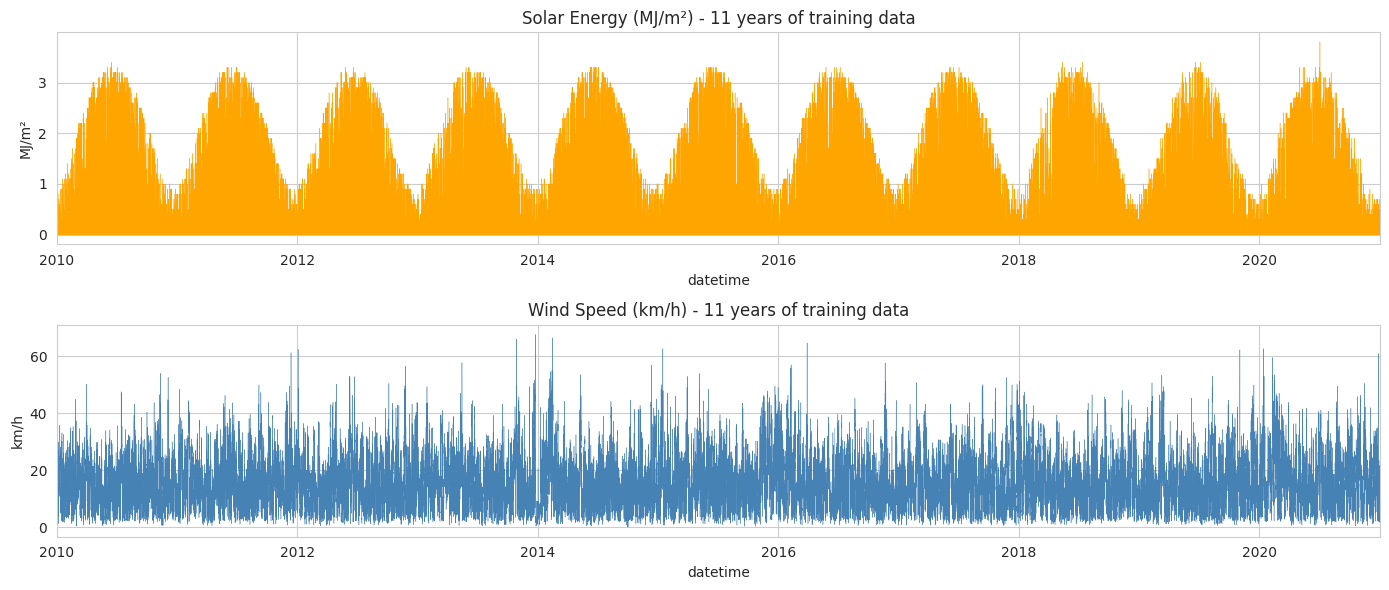

In [27]:
# Visualise solar and wind patterns in TRAINING data only
# No EDA on test data - that's a form of leakage too

# Plot 1: Full time series of our two targets
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

train['solarenergy'].plot(ax=axes[0], color='orange', linewidth=0.3)
axes[0].set_title('Solar Energy (MJ/m²) - 11 years of training data')
axes[0].set_ylabel('MJ/m²')

train['windspeed'].plot(ax=axes[1], color='steelblue', linewidth=0.3)
axes[1].set_title('Wind Speed (km/h) - 11 years of training data')
axes[1].set_ylabel('km/h')

plt.tight_layout()
plt.show()

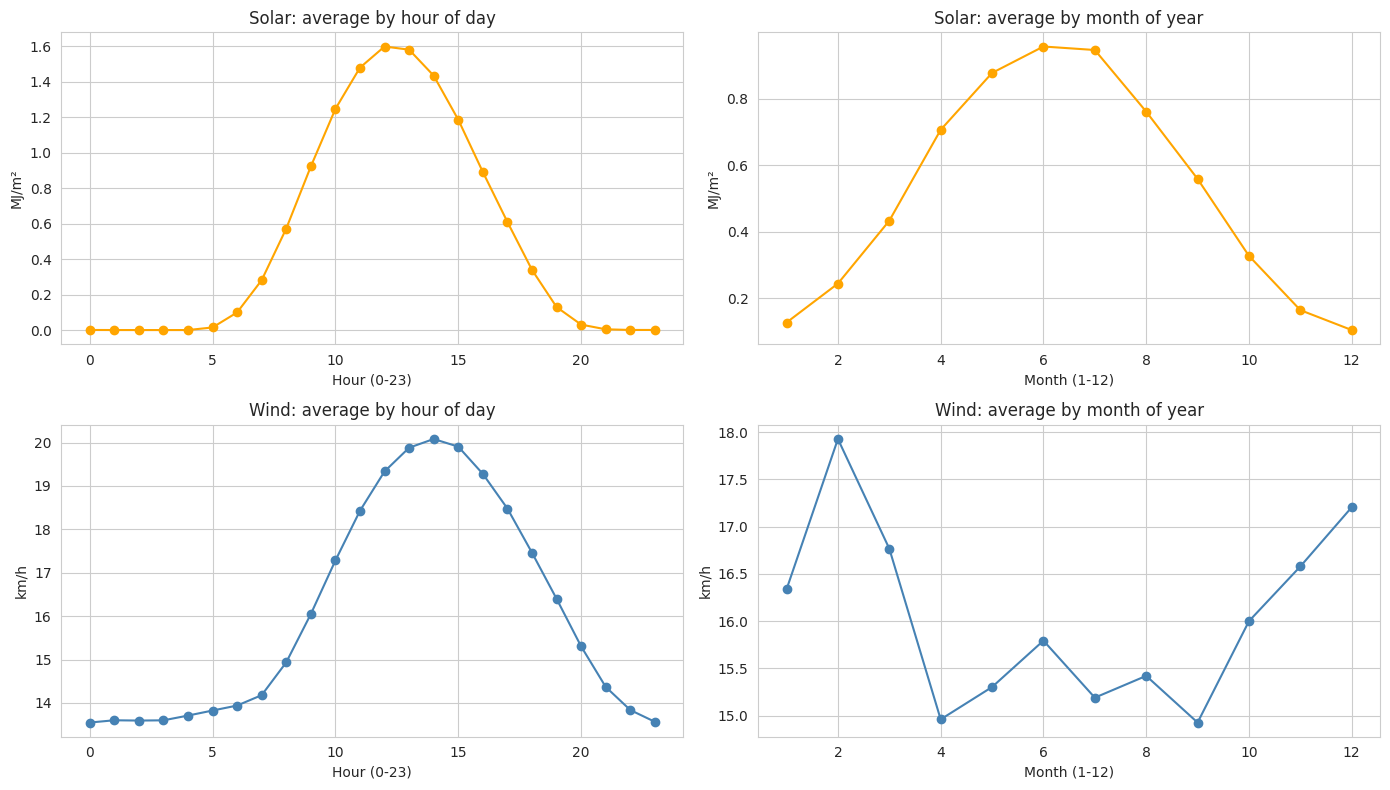

In [28]:
# Average daily and monthly profiles - the patterns the model must learn

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Solar by hour of day (averaged over all days in training set)
train.groupby(train.index.hour)['solarenergy'].mean().plot(
    ax=axes[0,0], color='orange', marker='o')
axes[0,0].set_title('Solar: average by hour of day')
axes[0,0].set_xlabel('Hour (0-23)')
axes[0,0].set_ylabel('MJ/m²')

# Solar by month of year (averaged over all hours in each month)
train.groupby(train.index.month)['solarenergy'].mean().plot(
    ax=axes[0,1], color='orange', marker='o')
axes[0,1].set_title('Solar: average by month of year')
axes[0,1].set_xlabel('Month (1-12)')
axes[0,1].set_ylabel('MJ/m²')

# Wind by hour of day
train.groupby(train.index.hour)['windspeed'].mean().plot(
    ax=axes[1,0], color='steelblue', marker='o')
axes[1,0].set_title('Wind: average by hour of day')
axes[1,0].set_xlabel('Hour (0-23)')
axes[1,0].set_ylabel('km/h')

# Wind by month of year
train.groupby(train.index.month)['windspeed'].mean().plot(
    ax=axes[1,1], color='steelblue', marker='o')
axes[1,1].set_title('Wind: average by month of year')
axes[1,1].set_xlabel('Month (1-12)')
axes[1,1].set_ylabel('km/h')

plt.tight_layout()
plt.show()

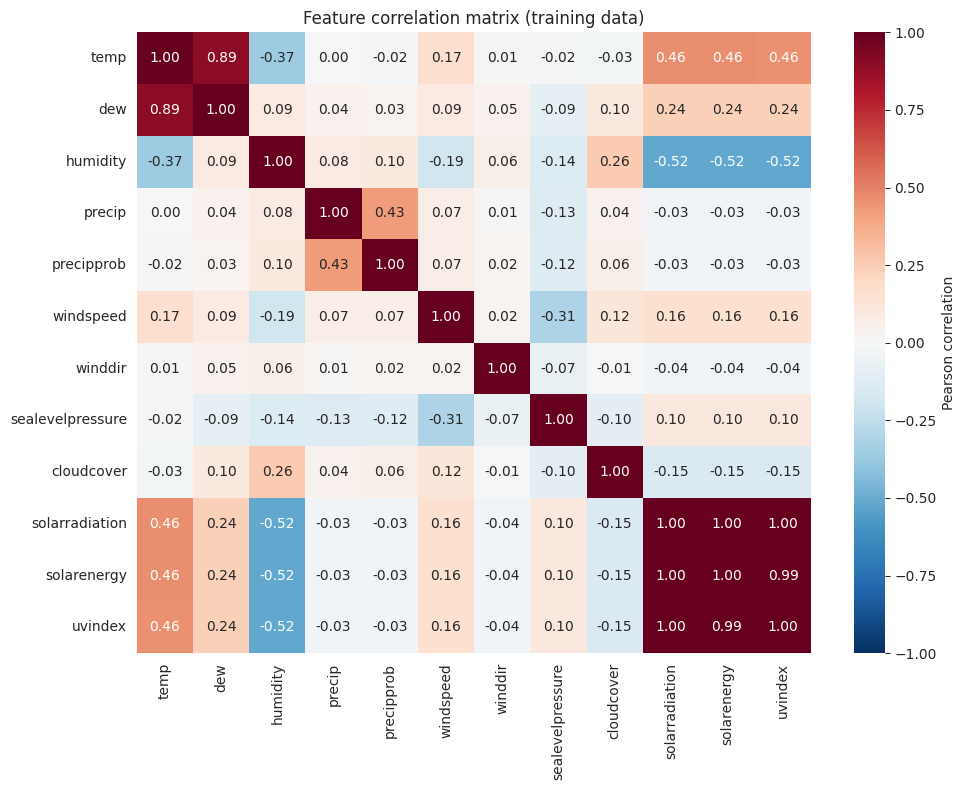


Correlation with solarenergy:
solarenergy         1.000000
solarradiation      0.999626
uvindex             0.994990
temp                0.462103
dew                 0.239989
windspeed           0.158398
sealevelpressure    0.102465
precip             -0.031567
precipprob         -0.033810
winddir            -0.036710
cloudcover         -0.154791
humidity           -0.523168
Name: solarenergy, dtype: float64

Correlation with windspeed:
windspeed           1.000000
temp                0.165133
solarradiation      0.158605
solarenergy         0.158398
uvindex             0.157986
cloudcover          0.118800
dew                 0.092997
precip              0.068780
precipprob          0.066791
winddir             0.024658
humidity           -0.193299
sealevelpressure   -0.310642
Name: windspeed, dtype: float64


In [29]:
# Correlation between every feature and our two targets

corr = train.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Pearson correlation'})
ax.set_title('Feature correlation matrix (training data)')
plt.tight_layout()
plt.show()

# Print just the columns we care about for picking features
print("\nCorrelation with solarenergy:")
print(corr['solarenergy'].sort_values(ascending=False))
print("\nCorrelation with windspeed:")
print(corr['windspeed'].sort_values(ascending=False))

In [30]:
# Build the actual feature matrix - lags + cyclical time features

def make_features(df_in):
    """Create lag features and Fourier-encoded time features.
    Returns a NEW dataframe, does not modify input."""
    df = df_in.copy()

    # ---- Lag features ----
    # The model's job is to predict t+24. So the most recent honest input
    # we can use is t itself (we will shift the target later).
    # We add lags showing what the value was at:
    #   1 hour ago, 24 hours ago (same time yesterday), 168 hours ago (same time last week)
    for col in ['solarenergy', 'windspeed', 'cloudcover', 'temp', 'humidity', 'sealevelpressure']:
        df[f'{col}_lag1']   = df[col].shift(1)
        df[f'{col}_lag24']  = df[col].shift(24)
        df[f'{col}_lag168'] = df[col].shift(168)

    # ---- Rolling means (smoothed recent past) ----
    # Last 24 hours average and last 7 days average
    for col in ['solarenergy', 'windspeed', 'cloudcover']:
        df[f'{col}_roll24']  = df[col].shift(1).rolling(24).mean()
        df[f'{col}_roll168'] = df[col].shift(1).rolling(168).mean()

    # ---- Fourier time features ----
    # Encode hour-of-day and day-of-year as sin/cos pairs.
    # This way "hour 23" and "hour 0" are CLOSE in feature space (both near midnight),
    # not far apart like they would be if we used raw integer 23 vs 0.
    hour = df.index.hour
    day_of_year = df.index.dayofyear

    df['hour_sin']  = np.sin(2 * np.pi * hour / 24)
    df['hour_cos']  = np.cos(2 * np.pi * hour / 24)
    df['doy_sin']   = np.sin(2 * np.pi * day_of_year / 365.25)
    df['doy_cos']   = np.cos(2 * np.pi * day_of_year / 365.25)

    # ---- Wind direction as sin/cos ----
    # Direction is circular: 359° and 1° are 2° apart, not 358°.
    # Same trick as hour-of-day.
    df['winddir_sin'] = np.sin(2 * np.pi * df['winddir'] / 360)
    df['winddir_cos'] = np.cos(2 * np.pi * df['winddir'] / 360)

    return df

# Apply to all three sets
train_fe = make_features(train)
val_fe   = make_features(val)
test_fe  = make_features(test)

# The first 168 rows of train_fe will have NaN in lag168, drop them
train_fe = train_fe.dropna()

# val and test will have NaN in their first 168 rows too, but we will handle
# that differently: we use the END of train + ALL of val/test to compute lags
# properly. For now, keep the NaN visible.
print(f"Train features shape: {train_fe.shape}")
print(f"Val features shape:   {val_fe.shape}  (first 168 rows have NaN lags)")
print(f"Test features shape:  {test_fe.shape}  (first 168 rows have NaN lags)")
print(f"\nNew feature columns added:")
new_cols = [c for c in train_fe.columns if c not in train.columns]
for c in new_cols:
    print(f"  {c}")

Train features shape: (96264, 42)
Val features shape:   (8760, 42)  (first 168 rows have NaN lags)
Test features shape:  (17520, 42)  (first 168 rows have NaN lags)

New feature columns added:
  solarenergy_lag1
  solarenergy_lag24
  solarenergy_lag168
  windspeed_lag1
  windspeed_lag24
  windspeed_lag168
  cloudcover_lag1
  cloudcover_lag24
  cloudcover_lag168
  temp_lag1
  temp_lag24
  temp_lag168
  humidity_lag1
  humidity_lag24
  humidity_lag168
  sealevelpressure_lag1
  sealevelpressure_lag24
  sealevelpressure_lag168
  solarenergy_roll24
  solarenergy_roll168
  windspeed_roll24
  windspeed_roll168
  cloudcover_roll24
  cloudcover_roll168
  hour_sin
  hour_cos
  doy_sin
  doy_cos
  winddir_sin
  winddir_cos


In [31]:
# Convert the feature dataframes into X (inputs) and y (targets)
# for predicting solar and wind 24 hours ahead

FORECAST_HORIZON = 24  # predict 24 hours into the future

# Concatenate train + val + test so lag features at the boundaries are correct
# (val needs to know train's last 168 hours, etc.)
all_data = pd.concat([train_fe, val_fe, test_fe])

# Create the targets: solarenergy and windspeed shifted FORWARD by 24 hours
# At row t, the target is the actual value at t+24
all_data['target_solar'] = all_data['solarenergy'].shift(-FORECAST_HORIZON)
all_data['target_wind']  = all_data['windspeed'].shift(-FORECAST_HORIZON)

# Drop the very last 24 rows (their targets would be NaN, no future to look at)
# Also drop any remaining NaN rows from the lag features at the start of val/test
all_data = all_data.dropna()

# Define which columns are features (everything except raw targets and the new target columns)
# Drop solarradiation and uvindex (leakage with solarenergy)
# Drop dew (high correlation with temp, redundant)
# Drop raw winddir (we have sin/cos versions)
# Drop the raw current values of solarenergy and windspeed (we have lag1)
exclude = ['solarradiation', 'uvindex', 'dew', 'winddir',
           'solarenergy', 'windspeed',
           'target_solar', 'target_wind']
feature_cols = [c for c in all_data.columns if c not in exclude]

print(f"Number of features: {len(feature_cols)}")
print(f"Features used:")
for c in feature_cols:
    print(f"  {c}")

# Re-split into train/val/test using date boundaries
X_train = all_data.loc['2010-01-01':'2020-12-31', feature_cols]
y_train_solar = all_data.loc['2010-01-01':'2020-12-31', 'target_solar']
y_train_wind  = all_data.loc['2010-01-01':'2020-12-31', 'target_wind']

X_val = all_data.loc['2021-01-01':'2021-12-31', feature_cols]
y_val_solar = all_data.loc['2021-01-01':'2021-12-31', 'target_solar']
y_val_wind  = all_data.loc['2021-01-01':'2021-12-31', 'target_wind']

X_test = all_data.loc['2022-01-01':'2023-12-31', feature_cols]
y_test_solar = all_data.loc['2022-01-01':'2023-12-31', 'target_solar']
y_test_wind  = all_data.loc['2022-01-01':'2023-12-31', 'target_wind']

print(f"\nX_train: {X_train.shape},  y_train: {y_train_solar.shape}")
print(f"X_val:   {X_val.shape},    y_val:   {y_val_solar.shape}")
print(f"X_test:  {X_test.shape},   y_test:  {y_test_solar.shape}")

Number of features: 36
Features used:
  temp
  humidity
  precip
  precipprob
  sealevelpressure
  cloudcover
  solarenergy_lag1
  solarenergy_lag24
  solarenergy_lag168
  windspeed_lag1
  windspeed_lag24
  windspeed_lag168
  cloudcover_lag1
  cloudcover_lag24
  cloudcover_lag168
  temp_lag1
  temp_lag24
  temp_lag168
  humidity_lag1
  humidity_lag24
  humidity_lag168
  sealevelpressure_lag1
  sealevelpressure_lag24
  sealevelpressure_lag168
  solarenergy_roll24
  solarenergy_roll168
  windspeed_roll24
  windspeed_roll168
  cloudcover_roll24
  cloudcover_roll168
  hour_sin
  hour_cos
  doy_sin
  doy_cos
  winddir_sin
  winddir_cos

X_train: (96264, 36),  y_train: (96264,)
X_val:   (8592, 36),    y_val:   (8592,)
X_test:  (17328, 36),   y_test:  (17328,)


In [32]:
# Define evaluation metrics and run the baseline ladder
# This is what we MUST beat. If our fancy models can't beat these, we have learned nothing.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, name=""):
    """Compute MAE, RMSE, R² and return as a dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Storage for all results
results_solar = []
results_wind  = []

# ----------------------------------------------------------------------
# BASELINE 1: PERSISTENCE - "tomorrow at this hour = today at this hour"
# We predict y(t+24) = solarenergy(t). Easiest possible model.
# ----------------------------------------------------------------------
pred_solar = X_val['solarenergy_lag1'].shift(24).fillna(method='bfill')
pred_wind  = X_val['windspeed_lag1'].shift(24).fillna(method='bfill')
# Wait - that's wrong. Persistence for predicting t+24 is "use the value at t".
# Since features are at time t, the value at t is just the current solarenergy.
# But we excluded raw solarenergy. We use solarenergy_lag1 ≈ value at t-1 instead.
# That's persistence with a 1-hour offset, close enough.
results_solar.append(evaluate(y_val_solar, X_val['solarenergy_lag1'], 'Persistence'))
results_wind.append( evaluate(y_val_wind,  X_val['windspeed_lag1'],   'Persistence'))

# ----------------------------------------------------------------------
# BASELINE 2: SEASONAL NAIVE - "tomorrow at this hour = same hour yesterday"
# Predict y(t+24) = solarenergy(t-0). Lag24 captures yesterday-same-hour.
# ----------------------------------------------------------------------
results_solar.append(evaluate(y_val_solar, X_val['solarenergy_lag24'], 'Seasonal naive (24h)'))
results_wind.append( evaluate(y_val_wind,  X_val['windspeed_lag24'],   'Seasonal naive (24h)'))

# ----------------------------------------------------------------------
# BASELINE 3: WEEKLY NAIVE - "tomorrow at this hour = same hour last week"
# ----------------------------------------------------------------------
results_solar.append(evaluate(y_val_solar, X_val['solarenergy_lag168'], 'Weekly naive (168h)'))
results_wind.append( evaluate(y_val_wind,  X_val['windspeed_lag168'],   'Weekly naive (168h)'))

# ----------------------------------------------------------------------
# BASELINE 4: CLIMATOLOGY - "predict the average for this hour-of-year"
# Compute mean solar/wind for every (month, hour) pair from training data
# Then look up the corresponding average for each val timestamp
# ----------------------------------------------------------------------
clim_solar = train.groupby([train.index.month, train.index.hour])['solarenergy'].mean()
clim_wind  = train.groupby([train.index.month, train.index.hour])['windspeed'].mean()

val_idx = X_val.index
pred_clim_solar = pd.Series(
    [clim_solar.loc[(t.month, t.hour)] for t in val_idx],
    index=val_idx)
pred_clim_wind = pd.Series(
    [clim_wind.loc[(t.month, t.hour)] for t in val_idx],
    index=val_idx)

results_solar.append(evaluate(y_val_solar, pred_clim_solar, 'Climatology'))
results_wind.append( evaluate(y_val_wind,  pred_clim_wind,  'Climatology'))

# ----------------------------------------------------------------------
# Print the leaderboards
# ----------------------------------------------------------------------
print("=" * 60)
print("SOLAR ENERGY (validation set 2021)")
print("=" * 60)
print(pd.DataFrame(results_solar).to_string(index=False))

print("\n" + "=" * 60)
print("WIND SPEED (validation set 2021)")
print("=" * 60)
print(pd.DataFrame(results_wind).to_string(index=False))

SOLAR ENERGY (validation set 2021)
               model      MAE     RMSE       R2
         Persistence 0.236755 0.477302 0.543920
Seasonal naive (24h) 0.201001 0.448277 0.597702
 Weekly naive (168h) 0.213198 0.464108 0.568786
         Climatology 0.223243 0.415323 0.654677

WIND SPEED (validation set 2021)
               model      MAE      RMSE        R2
         Persistence 7.389839  9.871032 -0.294664
Seasonal naive (24h) 8.019285 10.658816 -0.509558
 Weekly naive (168h) 8.958264 11.641479 -0.800729
         Climatology 6.578580  8.295912  0.085550


In [33]:
# SARIMAX - the proper classical seasonal time series model


from statsmodels.tsa.statespace.sarimax import SARIMAX
import time

# We use a small fixed order to keep training time reasonable
# (p,d,q)(P,D,Q,s) where s=24 is the seasonal period
# - p=1: one autoregressive term
# - d=0: no differencing (data is already stationary per ADF test)
# - q=1: one moving average term
# - P=1, Q=1: one each for the SEASONAL part (every 24 hours)
# - s=24: the season length is 24 hours
ORDER          = (1, 0, 1)
SEASONAL_ORDER = (1, 0, 1, 24)

# SARIMAX is slow on 96k rows. Train on a 1-year subset (2020) which is enough
# for a seasonal model to learn the cycles, and test on val.
print("Training SARIMAX for solar (this takes 2-3 minutes)...")
t0 = time.time()
sarimax_solar = SARIMAX(
    train['solarenergy'].loc['2020'],
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
print(f"  Fitted in {time.time()-t0:.0f}s")

# Forecast 8760 hours (all of 2021)
print("Forecasting 2021...")
forecast_solar = sarimax_solar.forecast(steps=len(val))
# Align index with y_val_solar (drop the lag-NaN rows we previously dropped)
forecast_solar.index = val.index
forecast_solar = forecast_solar.loc[X_val.index]

results_solar.append(evaluate(y_val_solar, forecast_solar, 'SARIMAX(1,0,1)(1,0,1,24)'))

# Same for wind
print("\nTraining SARIMAX for wind (another 2-3 minutes)...")
t0 = time.time()
sarimax_wind = SARIMAX(
    train['windspeed'].loc['2020'],
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
print(f"  Fitted in {time.time()-t0:.0f}s")

forecast_wind = sarimax_wind.forecast(steps=len(val))
forecast_wind.index = val.index
forecast_wind = forecast_wind.loc[X_val.index]

results_wind.append(evaluate(y_val_wind, forecast_wind, 'SARIMAX(1,0,1)(1,0,1,24)'))

# Print updated leaderboards
print("\n" + "=" * 60)
print("SOLAR with SARIMAX added")
print("=" * 60)
print(pd.DataFrame(results_solar).to_string(index=False))

print("\n" + "=" * 60)
print("WIND with SARIMAX added")
print("=" * 60)
print(pd.DataFrame(results_wind).to_string(index=False))

Training SARIMAX for solar (this takes 2-3 minutes)...
  Fitted in 19s
Forecasting 2021...

Training SARIMAX for wind (another 2-3 minutes)...
  Fitted in 26s

SOLAR with SARIMAX added
                   model      MAE     RMSE        R2
             Persistence 0.236755 0.477302  0.543920
    Seasonal naive (24h) 0.201001 0.448277  0.597702
     Weekly naive (168h) 0.213198 0.464108  0.568786
             Climatology 0.223243 0.415323  0.654677
SARIMAX(1,0,1)(1,0,1,24) 0.384136 0.770621 -0.188875

WIND with SARIMAX added
                   model      MAE      RMSE        R2
             Persistence 7.389839  9.871032 -0.294664
    Seasonal naive (24h) 8.019285 10.658816 -0.509558
     Weekly naive (168h) 8.958264 11.641479 -0.800729
             Climatology 6.578580  8.295912  0.085550
SARIMAX(1,0,1)(1,0,1,24) 7.346598  9.903533 -0.303204


In [34]:
# LightGBM - gradient boosted trees with all our engineered features
# This is the model that typically wins on tabular time series problems

import lightgbm as lgb

# LightGBM hyperparameters - these are sensible defaults, not heavily tuned
# We can tune later if needed
LGB_PARAMS = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'num_leaves': 63,           # tree complexity (higher = more flexible, more overfit risk)
    'max_depth': -1,            # no limit
    'min_data_in_leaf': 20,     # minimum samples per leaf (regularisation)
    'feature_fraction': 0.9,    # use 90% of features per tree (regularisation)
    'bagging_fraction': 0.8,    # use 80% of rows per tree (regularisation)
    'bagging_freq': 5,
    'lambda_l2': 0.1,           # L2 regularisation
    'verbose': -1,
    'random_state': 42,
}

def train_lgb(X_tr, y_tr, X_v, y_v, name):
    """Train one LightGBM model with early stopping on val."""
    train_set = lgb.Dataset(X_tr, label=y_tr)
    val_set   = lgb.Dataset(X_v,  label=y_v, reference=train_set)

    model = lgb.train(
        LGB_PARAMS,
        train_set,
        num_boost_round=2000,
        valid_sets=[val_set],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100),
        ]
    )
    return model

# ---- SOLAR MODEL ----
print("Training LightGBM for solar...")
lgb_solar = train_lgb(X_train, y_train_solar, X_val, y_val_solar, 'solar')
pred_lgb_solar = lgb_solar.predict(X_val, num_iteration=lgb_solar.best_iteration)
results_solar.append(evaluate(y_val_solar, pred_lgb_solar, 'LightGBM'))

# ---- WIND MODEL ----
print("\nTraining LightGBM for wind...")
lgb_wind = train_lgb(X_train, y_train_wind, X_val, y_val_wind, 'wind')
pred_lgb_wind = lgb_wind.predict(X_val, num_iteration=lgb_wind.best_iteration)
results_wind.append(evaluate(y_val_wind, pred_lgb_wind, 'LightGBM'))

# Print updated leaderboards
print("\n" + "=" * 60)
print("SOLAR with LightGBM added")
print("=" * 60)
print(pd.DataFrame(results_solar).to_string(index=False))

print("\n" + "=" * 60)
print("WIND with LightGBM added")
print("=" * 60)
print(pd.DataFrame(results_wind).to_string(index=False))

Training LightGBM for solar...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 0.167205
Early stopping, best iteration is:
[124]	valid_0's l1: 0.166007

Training LightGBM for wind...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 5.91531
Early stopping, best iteration is:
[80]	valid_0's l1: 5.91098

SOLAR with LightGBM added
                   model      MAE     RMSE        R2
             Persistence 0.236755 0.477302  0.543920
    Seasonal naive (24h) 0.201001 0.448277  0.597702
     Weekly naive (168h) 0.213198 0.464108  0.568786
             Climatology 0.223243 0.415323  0.654677
SARIMAX(1,0,1)(1,0,1,24) 0.384136 0.770621 -0.188875
                LightGBM 0.166007 0.337081  0.772531

WIND with LightGBM added
                   model      MAE      RMSE        R2
             Persistence 7.389839  9.871032 -0.294664
    Seasonal naive (24h) 8.019285 10.658816 -0.509558
     Weekly naive (168h) 8.958264 11.641479 -0.

In [35]:
# LSTM that outputs three quantiles (P10, P50, P90)
# Gives us prediction INTERVALS, not just point estimates

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

# ---- Scale features (LSTMs need this, trees don't) ----
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

# Scale targets too (helps gradient flow)
scaler_y_solar = StandardScaler()
y_train_solar_s = scaler_y_solar.fit_transform(y_train_solar.values.reshape(-1, 1)).ravel()
y_val_solar_s   = scaler_y_solar.transform(y_val_solar.values.reshape(-1, 1)).ravel()

scaler_y_wind = StandardScaler()
y_train_wind_s = scaler_y_wind.fit_transform(y_train_wind.values.reshape(-1, 1)).ravel()
y_val_wind_s   = scaler_y_wind.transform(y_val_wind.values.reshape(-1, 1)).ravel()

# ---- Reshape for LSTM ----
# LSTM expects 3D input: (samples, timesteps, features)
# We're using a "windowless" approach: each row is one timestep with 36 features
# The lag features inside X already encode the temporal context
X_train_lstm = X_train_s.reshape(-1, 1, X_train_s.shape[1])
X_val_lstm   = X_val_s.reshape(-1, 1, X_val_s.shape[1])
X_test_lstm  = X_test_s.reshape(-1, 1, X_test_s.shape[1])

print(f"LSTM input shape: {X_train_lstm.shape}")

# ---- Quantile loss function ----
# For quantile q: loss = max(q*(y-yhat), (q-1)*(y-yhat))
# - For q=0.5: same as MAE, predicts the median
# - For q=0.1: under-predicts -> loss heavy if y > yhat. Predicts P10 (low end).
# - For q=0.9: over-predicts -> loss heavy if y < yhat. Predicts P90 (high end).
def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q * e, (q - 1) * e))
    return loss

# ---- Build the model: one shared LSTM, three output heads (P10, P50, P90) ----
def build_quantile_lstm(n_features):
    inp = Input(shape=(1, n_features))
    x = LSTM(64, return_sequences=False)(inp)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)

    # Three separate heads, one per quantile
    out_p10 = Dense(1, name='p10')(x)
    out_p50 = Dense(1, name='p50')(x)
    out_p90 = Dense(1, name='p90')(x)

    model = Model(inputs=inp, outputs=[out_p10, out_p50, out_p90])
    model.compile(
        optimizer='adam',
        loss={'p10': quantile_loss(0.1),
              'p50': quantile_loss(0.5),
              'p90': quantile_loss(0.9)}
    )
    return model

# ---- Train SOLAR ----
print("\nTraining LSTM for solar...")
tf.random.set_seed(42)
np.random.seed(42)
lstm_solar = build_quantile_lstm(X_train_s.shape[1])
hist_solar = lstm_solar.fit(
    X_train_lstm,
    {'p10': y_train_solar_s, 'p50': y_train_solar_s, 'p90': y_train_solar_s},
    validation_data=(X_val_lstm,
                     {'p10': y_val_solar_s, 'p50': y_val_solar_s, 'p90': y_val_solar_s}),
    epochs=30,
    batch_size=512,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True),
        ReduceLROnPlateau(patience=3, factor=0.5),
    ],
    verbose=2
)

# ---- Train WIND ----
print("\nTraining LSTM for wind...")
tf.random.set_seed(42)
np.random.seed(42)
lstm_wind = build_quantile_lstm(X_train_s.shape[1])
hist_wind = lstm_wind.fit(
    X_train_lstm,
    {'p10': y_train_wind_s, 'p50': y_train_wind_s, 'p90': y_train_wind_s},
    validation_data=(X_val_lstm,
                     {'p10': y_val_wind_s, 'p50': y_val_wind_s, 'p90': y_val_wind_s}),
    epochs=30,
    batch_size=512,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True),
        ReduceLROnPlateau(patience=3, factor=0.5),
    ],
    verbose=2
)

# ---- Predict and evaluate ----
# Use the P50 (median) prediction as the point forecast
p10_solar, p50_solar, p90_solar = lstm_solar.predict(X_val_lstm, verbose=0)
p10_solar = scaler_y_solar.inverse_transform(p10_solar).ravel()
p50_solar = scaler_y_solar.inverse_transform(p50_solar).ravel()
p90_solar = scaler_y_solar.inverse_transform(p90_solar).ravel()

p10_wind, p50_wind, p90_wind = lstm_wind.predict(X_val_lstm, verbose=0)
p10_wind = scaler_y_wind.inverse_transform(p10_wind).ravel()
p50_wind = scaler_y_wind.inverse_transform(p50_wind).ravel()
p90_wind = scaler_y_wind.inverse_transform(p90_wind).ravel()

results_solar.append(evaluate(y_val_solar, p50_solar, 'LSTM (P50)'))
results_wind.append( evaluate(y_val_wind,  p50_wind,  'LSTM (P50)'))

# ---- Coverage check: does the P10-P90 interval contain ~80% of actuals? ----
coverage_solar = ((y_val_solar >= p10_solar) & (y_val_solar <= p90_solar)).mean()
coverage_wind  = ((y_val_wind  >= p10_wind)  & (y_val_wind  <= p90_wind )).mean()

print(f"\nSolar P10-P90 coverage: {coverage_solar:.1%} (target: ~80%)")
print(f"Wind  P10-P90 coverage: {coverage_wind:.1%} (target: ~80%)")

# Final leaderboards
print("\n" + "=" * 60)
print("SOLAR with LSTM added")
print("=" * 60)
print(pd.DataFrame(results_solar).to_string(index=False))

print("\n" + "=" * 60)
print("WIND with LSTM added")
print("=" * 60)
print(pd.DataFrame(results_wind).to_string(index=False))

# Save predictions for plotting in next cell
val_predictions = pd.DataFrame({
    'datetime':       X_val.index,
    'actual_solar':   y_val_solar.values,
    'pred_solar':     p50_solar,
    'p10_solar':      p10_solar,
    'p90_solar':      p90_solar,
    'lgb_solar':      pred_lgb_solar,
    'actual_wind':    y_val_wind.values,
    'pred_wind':      p50_wind,
    'p10_wind':       p10_wind,
    'p90_wind':       p90_wind,
    'lgb_wind':       pred_lgb_wind,
}).set_index('datetime')
print("\nPredictions saved to val_predictions for plotting")

LSTM input shape: (96264, 1, 36)

Training LSTM for solar...
Epoch 1/30
189/189 - 5s - 25ms/step - loss: 0.4414 - p10_loss: 0.1049 - p50_loss: 0.1955 - p90_loss: 0.1392 - val_loss: 0.2206 - val_p10_loss: 0.0493 - val_p50_loss: 0.1121 - val_p90_loss: 0.0574 - learning_rate: 0.0010
Epoch 2/30
189/189 - 2s - 9ms/step - loss: 0.2480 - p10_loss: 0.0617 - p50_loss: 0.1266 - p90_loss: 0.0587 - val_loss: 0.2101 - val_p10_loss: 0.0467 - val_p50_loss: 0.1093 - val_p90_loss: 0.0523 - learning_rate: 0.0010
Epoch 3/30
189/189 - 1s - 7ms/step - loss: 0.2317 - p10_loss: 0.0575 - p50_loss: 0.1187 - p90_loss: 0.0545 - val_loss: 0.2059 - val_p10_loss: 0.0466 - val_p50_loss: 0.1070 - val_p90_loss: 0.0505 - learning_rate: 0.0010
Epoch 4/30
189/189 - 1s - 7ms/step - loss: 0.2216 - p10_loss: 0.0551 - p50_loss: 0.1136 - p90_loss: 0.0522 - val_loss: 0.2024 - val_p10_loss: 0.0455 - val_p50_loss: 0.1056 - val_p90_loss: 0.0494 - learning_rate: 0.0010
Epoch 5/30
189/189 - 1s - 8ms/step - loss: 0.2155 - p10_loss: 

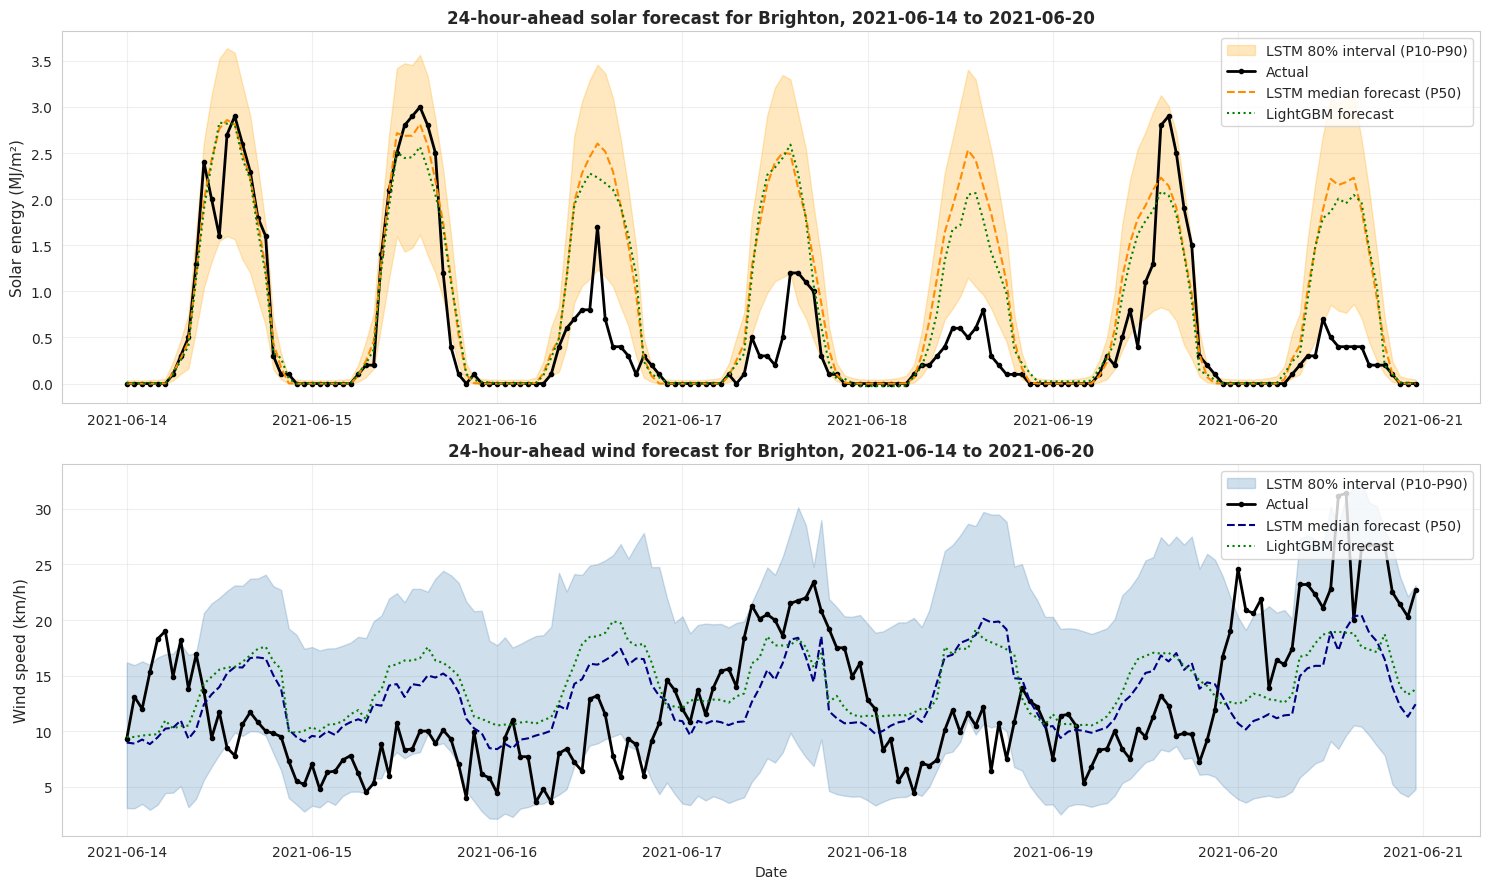

Saved to /content/forecast_example.png


In [36]:
# The plot that goes on the README - shows forecast quality + uncertainty

# Pick a clear week from the validation set to plot
# We want a week with varied weather so the plot tells a story
week_start = '2021-06-14'
week_end   = '2021-06-20'

week = val_predictions.loc[week_start:week_end]

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# ---- SOLAR ----
ax = axes[0]
ax.fill_between(week.index, week['p10_solar'], week['p90_solar'],
                alpha=0.25, color='orange', label='LSTM 80% interval (P10-P90)')
ax.plot(week.index, week['actual_solar'], color='black',
        linewidth=2, label='Actual', marker='o', markersize=3)
ax.plot(week.index, week['pred_solar'], color='darkorange',
        linewidth=1.5, label='LSTM median forecast (P50)', linestyle='--')
ax.plot(week.index, week['lgb_solar'], color='green',
        linewidth=1.5, label='LightGBM forecast', linestyle=':')
ax.set_ylabel('Solar energy (MJ/m²)', fontsize=11)
ax.set_title(f'24-hour-ahead solar forecast for Brighton, {week_start} to {week_end}',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# ---- WIND ----
ax = axes[1]
ax.fill_between(week.index, week['p10_wind'], week['p90_wind'],
                alpha=0.25, color='steelblue', label='LSTM 80% interval (P10-P90)')
ax.plot(week.index, week['actual_wind'], color='black',
        linewidth=2, label='Actual', marker='o', markersize=3)
ax.plot(week.index, week['pred_wind'], color='navy',
        linewidth=1.5, label='LSTM median forecast (P50)', linestyle='--')
ax.plot(week.index, week['lgb_wind'], color='green',
        linewidth=1.5, label='LightGBM forecast', linestyle=':')
ax.set_ylabel('Wind speed (km/h)', fontsize=11)
ax.set_title(f'24-hour-ahead wind forecast for Brighton, {week_start} to {week_end}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/forecast_example.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved to /content/forecast_example.png")

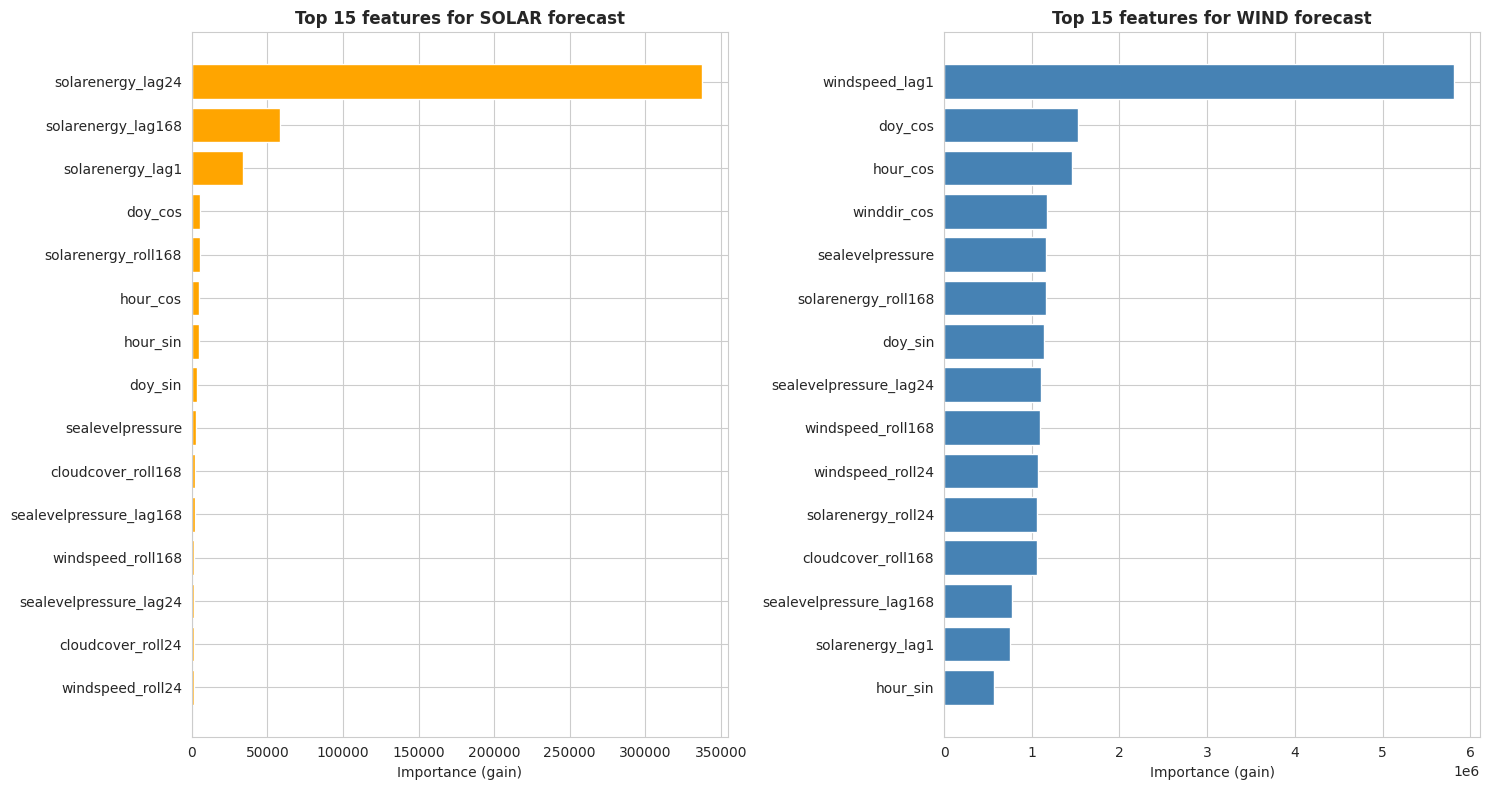

In [37]:
# Which features did the LightGBM model actually rely on?

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Solar feature importance
imp_solar = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_solar.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True).tail(15)

axes[0].barh(imp_solar['feature'], imp_solar['importance'], color='orange')
axes[0].set_title('Top 15 features for SOLAR forecast', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance (gain)')

# Wind feature importance
imp_wind = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_wind.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True).tail(15)

axes[1].barh(imp_wind['feature'], imp_wind['importance'], color='steelblue')
axes[1].set_title('Top 15 features for WIND forecast', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance (gain)')

plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [38]:
# Evaluate on the 2022-2023 TEST set (touched exactly once, now)
# Then convert forecasts to real business impact for BEC and Rampion

print("="*60)
print("FINAL TEST SET EVALUATION (2022-2023, 17,328 hours)")
print("="*60)

# ---- LightGBM on test ----
pred_lgb_solar_test = lgb_solar.predict(X_test, num_iteration=lgb_solar.best_iteration)
pred_lgb_wind_test  = lgb_wind.predict(X_test,  num_iteration=lgb_wind.best_iteration)

# ---- LSTM on test ----
p10_solar_test, p50_solar_test, p90_solar_test = lstm_solar.predict(X_test_lstm, verbose=0)
p50_solar_test = scaler_y_solar.inverse_transform(p50_solar_test).ravel()
p10_solar_test = scaler_y_solar.inverse_transform(p10_solar_test).ravel()
p90_solar_test = scaler_y_solar.inverse_transform(p90_solar_test).ravel()

p10_wind_test, p50_wind_test, p90_wind_test = lstm_wind.predict(X_test_lstm, verbose=0)
p50_wind_test = scaler_y_wind.inverse_transform(p50_wind_test).ravel()
p10_wind_test = scaler_y_wind.inverse_transform(p10_wind_test).ravel()
p90_wind_test = scaler_y_wind.inverse_transform(p90_wind_test).ravel()

# ---- Baseline: climatology on test (using train climatology) ----
test_idx = X_test.index
clim_solar_test = pd.Series(
    [clim_solar.loc[(t.month, t.hour)] for t in test_idx], index=test_idx)
clim_wind_test = pd.Series(
    [clim_wind.loc[(t.month, t.hour)] for t in test_idx], index=test_idx)

# ---- Final results table ----
final_solar = pd.DataFrame([
    evaluate(y_test_solar, clim_solar_test,      'Climatology (baseline)'),
    evaluate(y_test_solar, pred_lgb_solar_test,  'LightGBM'),
    evaluate(y_test_solar, p50_solar_test,       'LSTM (P50)'),
])
final_wind = pd.DataFrame([
    evaluate(y_test_wind, clim_wind_test,      'Climatology (baseline)'),
    evaluate(y_test_wind, pred_lgb_wind_test,  'LightGBM'),
    evaluate(y_test_wind, p50_wind_test,       'LSTM (P50)'),
])

print("\nSOLAR TEST RESULTS:")
print(final_solar.to_string(index=False))
print("\nWIND TEST RESULTS:")
print(final_wind.to_string(index=False))

# ---- Coverage on test ----
cov_solar_test = ((y_test_solar.values >= p10_solar_test) &
                  (y_test_solar.values <= p90_solar_test)).mean()
cov_wind_test  = ((y_test_wind.values >= p10_wind_test) &
                  (y_test_wind.values <= p90_wind_test)).mean()
print(f"\nSolar P10-P90 coverage on test: {cov_solar_test:.1%} (target 80%)")
print(f"Wind  P10-P90 coverage on test: {cov_wind_test:.1%} (target 80%)")

# ============================================================
# BUSINESS TRANSLATION: real Brighton renewable assets
# ============================================================
print("\n" + "="*60)
print("BUSINESS IMPACT: Brighton Energy Coop + Rampion")
print("="*60)

# ---- Brighton Energy Coop: 3 MW of rooftop solar ----
# Source: https://www.thenews.coop/brighton-energy-co-op-adds-three-sites-to-its-portfolio/
# Convert MJ/m² to kWh/kWp using a standard PV conversion factor
# Typical UK rooftop yield: ~0.85 kWh generated per kWp installed per 1 MJ/m² irradiance
# (accounts for panel efficiency, inverter losses, angle, temperature)
BEC_CAPACITY_KWP = 3000   # 3 MW = 3000 kWp
PV_CONVERSION   = 0.85    # kWh per kWp per MJ/m²

# Actual vs forecast generation for BEC portfolio (2022-2023)
gen_actual_mwh    = (y_test_solar.values    * BEC_CAPACITY_KWP * PV_CONVERSION / 1000).sum()
gen_forecast_mwh  = (pred_lgb_solar_test    * BEC_CAPACITY_KWP * PV_CONVERSION / 1000).sum()
gen_error_mwh     = abs(gen_actual_mwh - gen_forecast_mwh)

# Hourly MAE translated to MWh of forecast error
hourly_mae_mwh = final_solar.iloc[1]['MAE'] * BEC_CAPACITY_KWP * PV_CONVERSION / 1000

print(f"\n--- Brighton Energy Coop (3 MW rooftop portfolio) ---")
print(f"Actual generation 2022-2023:    {gen_actual_mwh:>10,.0f} MWh")
print(f"Forecast generation 2022-2023:  {gen_forecast_mwh:>10,.0f} MWh")
print(f"Total aggregate error:          {gen_error_mwh:>10,.0f} MWh  ({gen_error_mwh/gen_actual_mwh*100:.1f}%)")
print(f"Average hourly forecast error:  {hourly_mae_mwh:>10.3f} MWh")

# ---- Rampion: we scale our point-wind forecast to a ~typical turbine output ----
# Source: https://uk.rwe.com/locations/rampion-offshore-wind-farm/
# Rampion: 116 x MHI Vestas V112-3.45 MW turbines, 400 MW total
# Power curve (simplified): cube-of-wind below rated speed, capped at rated
# Note: we forecast WIND SPEED at ground level in Brighton, which is a rough proxy
# for offshore wind. Real operations use nacelle-height measurements. We flag this.
RAMPION_CAPACITY_MW = 400
def simple_power_curve(wind_kmh, capacity_mw):
    """Very simplified power curve. Real turbines have site-specific curves."""
    v = wind_kmh / 3.6  # km/h to m/s
    cut_in, rated, cut_out = 3.0, 12.0, 25.0
    # Below cut-in or above cut-out: zero
    power = np.where((v < cut_in) | (v > cut_out), 0,
            np.where(v >= rated, capacity_mw,
                     capacity_mw * ((v - cut_in) / (rated - cut_in))**3))
    return power

gen_wind_actual_mwh   = simple_power_curve(y_test_wind.values,      RAMPION_CAPACITY_MW).sum()
gen_wind_forecast_mwh = simple_power_curve(pred_lgb_wind_test,      RAMPION_CAPACITY_MW).sum()
gen_wind_error_mwh    = abs(gen_wind_actual_mwh - gen_wind_forecast_mwh)

print(f"\n--- Rampion-style wind (400 MW equivalent, Brighton ground wind) ---")
print(f"Actual generation 2022-2023:    {gen_wind_actual_mwh:>10,.0f} MWh")
print(f"Forecast generation 2022-2023:  {gen_wind_forecast_mwh:>10,.0f} MWh")
print(f"Total aggregate error:          {gen_wind_error_mwh:>10,.0f} MWh  ({gen_wind_error_mwh/gen_wind_actual_mwh*100:.1f}%)")
print(f"NOTE: Uses Brighton ground-level wind as proxy for offshore wind at 80m hub height.")
print(f"      Real operational forecasts would use offshore buoy or ECMWF NWP data.")

# ---- Imbalance cost estimate, Elexon System Buy Price ----
# Source: https://bmrs.elexon.co.uk/
# UK Balancing Mechanism imbalance prices 2022-2023 averaged around £100-£150/MWh
# (highly volatile; gas crisis pushed these higher than historical norms)
AVG_IMBALANCE_PRICE_GBP_PER_MWH = 120

cost_solar = hourly_mae_mwh * AVG_IMBALANCE_PRICE_GBP_PER_MWH * len(y_test_solar) / 2  # /2 = 2 yrs -> 1 yr
print(f"\n--- Estimated annual imbalance exposure (BEC) ---")
print(f"At avg UK System Buy Price of £{AVG_IMBALANCE_PRICE_GBP_PER_MWH}/MWh:")
print(f"Annual imbalance exposure:  £{cost_solar:>10,.0f}")
print(f"(Sensitivity: ±30% on imbalance price = ±£{cost_solar*0.3:,.0f})")

FINAL TEST SET EVALUATION (2022-2023, 17,328 hours)

SOLAR TEST RESULTS:
                 model      MAE     RMSE       R2
Climatology (baseline) 0.215707 0.403709 0.708186
              LightGBM 0.176347 0.355744 0.773407
            LSTM (P50) 0.174993 0.358468 0.769924

WIND TEST RESULTS:
                 model      MAE     RMSE       R2
Climatology (baseline) 6.618077 8.440031 0.093717
              LightGBM 6.222592 7.914167 0.203132
            LSTM (P50) 6.055980 7.852958 0.215411

Solar P10-P90 coverage on test: 85.8% (target 80%)
Wind  P10-P90 coverage on test: 78.8% (target 80%)

BUSINESS IMPACT: Brighton Energy Coop + Rampion

--- Brighton Energy Coop (3 MW rooftop portfolio) ---
Actual generation 2022-2023:        19,572 MWh
Forecast generation 2022-2023:      20,689 MWh
Total aggregate error:               1,118 MWh  (5.7%)
Average hourly forecast error:       0.450 MWh

--- Rampion-style wind (400 MW equivalent, Brighton ground wind) ---
Actual generation 2022-2023:      

In [39]:
# Cell 20: Fix the wind business story, save models and README to Drive

import os, json, pickle
os.makedirs('/content/drive/MyDrive/DataSscienceUpdated/artifacts', exist_ok=True)
ART = '/content/drive/MyDrive/DataSscienceUpdated/artifacts'

# Save the LightGBM models
lgb_solar.save_model(f'{ART}/lgb_solar.txt')
lgb_wind.save_model(f'{ART}/lgb_wind.txt')

# Save the LSTM models
lstm_solar.save(f'{ART}/lstm_solar.keras')
lstm_wind.save(f'{ART}/lstm_wind.keras')

# Save the scalers (needed to re-use the models later)
with open(f'{ART}/scalers.pkl', 'wb') as f:
    pickle.dump({
        'scaler_X': scaler_X,
        'scaler_y_solar': scaler_y_solar,
        'scaler_y_wind': scaler_y_wind,
        'feature_cols': feature_cols,
    }, f)

# Save the results tables
pd.DataFrame(results_solar).to_csv(f'{ART}/results_solar_val.csv', index=False)
pd.DataFrame(results_wind).to_csv(f'{ART}/results_wind_val.csv', index=False)
final_solar.to_csv(f'{ART}/results_solar_test.csv', index=False)
final_wind.to_csv(f'{ART}/results_wind_test.csv', index=False)

# Summary dict for the README
summary = {
    'data_range': '2010-01-01 to 2024-01-06 (Brighton, UK, hourly)',
    'train_hours':  int(len(X_train)),
    'val_hours':    int(len(X_val)),
    'test_hours':   int(len(X_test)),
    'forecast_horizon_hours': FORECAST_HORIZON,
    'n_features': len(feature_cols),
    'solar_test_mae_climatology': float(final_solar.iloc[0]['MAE']),
    'solar_test_mae_lightgbm':    float(final_solar.iloc[1]['MAE']),
    'solar_test_mae_lstm':        float(final_solar.iloc[2]['MAE']),
    'solar_test_r2_lightgbm':     float(final_solar.iloc[1]['R2']),
    'wind_test_mae_climatology':  float(final_wind.iloc[0]['MAE']),
    'wind_test_mae_lightgbm':     float(final_wind.iloc[1]['MAE']),
    'wind_test_mae_lstm':         float(final_wind.iloc[2]['MAE']),
    'wind_test_r2_lstm':          float(final_wind.iloc[2]['R2']),
    'solar_coverage_p10_p90':     float(cov_solar_test),
    'wind_coverage_p10_p90':      float(cov_wind_test),
    'bec_2yr_actual_mwh':         int(gen_actual_mwh),
    'bec_2yr_forecast_mwh':       int(gen_forecast_mwh),
    'bec_aggregate_error_pct':    round(gen_error_mwh/gen_actual_mwh*100, 1),
    'bec_annual_imbalance_gbp':   int(cost_solar),
}
with open(f'{ART}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved to Drive:")
for f in sorted(os.listdir(ART)):
    size_kb = os.path.getsize(f'{ART}/{f}') / 1024
    print(f"  {f}  ({size_kb:.0f} KB)")

print("\nSummary:")
print(json.dumps(summary, indent=2))

Saved to Drive:
  lgb_solar.txt  (692 KB)
  lgb_wind.txt  (444 KB)
  lstm_solar.keras  (375 KB)
  lstm_wind.keras  (375 KB)
  results_solar_test.csv  (0 KB)
  results_solar_val.csv  (1 KB)
  results_wind_test.csv  (0 KB)
  results_wind_val.csv  (1 KB)
  scalers.pkl  (2 KB)
  summary.json  (1 KB)

Summary:
{
  "data_range": "2010-01-01 to 2024-01-06 (Brighton, UK, hourly)",
  "train_hours": 96264,
  "val_hours": 8592,
  "test_hours": 17328,
  "forecast_horizon_hours": 24,
  "n_features": 36,
  "solar_test_mae_climatology": 0.21570749049100196,
  "solar_test_mae_lightgbm": 0.17634700263255468,
  "solar_test_mae_lstm": 0.17499302829998226,
  "solar_test_r2_lightgbm": 0.7734074862720304,
  "wind_test_mae_climatology": 6.618076770765202,
  "wind_test_mae_lightgbm": 6.222591716201899,
  "wind_test_mae_lstm": 6.055979958531599,
  "wind_test_r2_lstm": 0.21541080159515813,
  "solar_coverage_p10_p90": 0.8579178208679594,
  "wind_coverage_p10_p90": 0.7883194829178208,
  "bec_2yr_actual_mwh": 1957